In [30]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv(r'C:\Users\BHUVAN\OneDrive\Desktop\BOOKs & pdfs\B.Tech_3rd_Year\Sem-5_M26\IICT_Internship\Titanic\train.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


Mean Age: 29.69911764705882
Median Age: 28.0


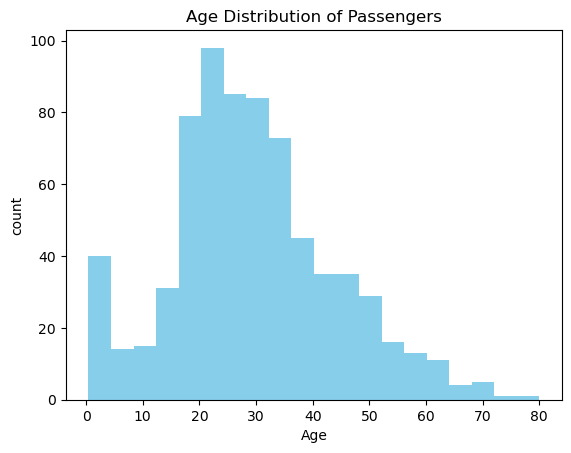

In [31]:
print("Mean Age:", df['Age'].mean())
print("Median Age:", df['Age'].median())
plt.hist(df['Age'], bins=20, color='skyblue')
plt.title('Age Distribution of Passengers')
plt.ylabel('count')
plt.xlabel('Age')
plt.show()

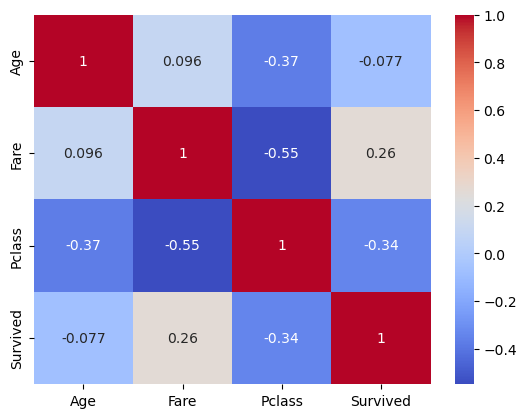

In [32]:
sns.heatmap(df[['Age', 'Fare', 'Pclass', 'Survived']].corr(), annot=True, cmap='coolwarm')
plt.show()

In [33]:
from scipy.stats import ttest_ind

male = df[df['Sex']=='male']['Survived']
female = df[df['Sex']=='female']['Survived']

t_stat, p_value = ttest_ind(female, male)
print(f"T-statistic: {t_stat}\nP-value: {p_value}")

T-statistic: 19.297816550123354
P-value: 1.4060661308802478e-69


In [34]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder

X = df[['Age', 'Fare', 'Pclass']] 
y = df['Survived']
X = X.fillna(X.mean()) 

model = LogisticRegression()
model.fit(X, y)
sample_passenger = pd.DataFrame([[25, 50, 2]], columns=['Age', 'Fare', 'Pclass'])
print(model.predict(sample_passenger))

[1]


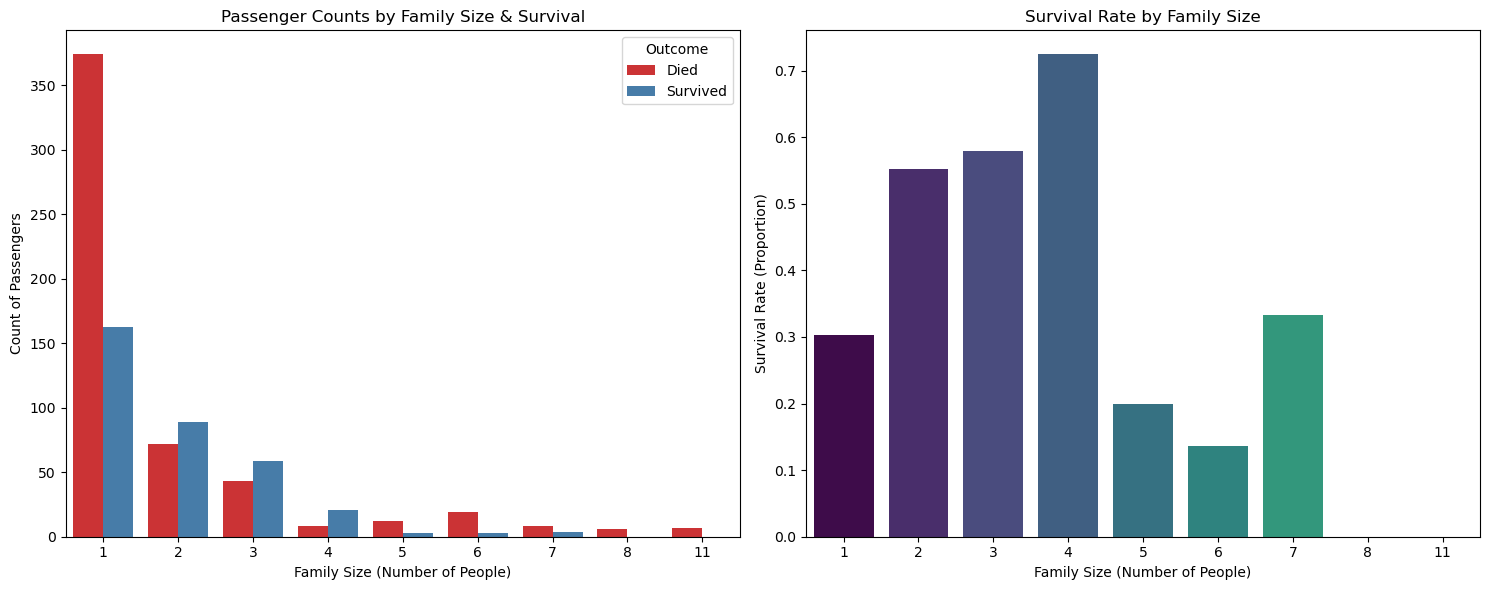

In [35]:
df['Family_Size'] = df['SibSp'] + df['Parch'] + 1

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
sns.countplot(data=df, x='Family_Size', hue='Survived', palette='Set1', ax=axes[0])
axes[0].set_title('Passenger Counts by Family Size & Survival')
axes[0].set_xlabel('Family Size (Number of People)')
axes[0].set_ylabel('Count of Passengers')
axes[0].legend(title='Outcome', labels=['Died', 'Survived'])

sns.barplot(data=df, x='Family_Size', y='Survived', palette='viridis', errorbar=None, ax=axes[1], hue='Family_Size', legend=False)
axes[1].set_title('Survival Rate by Family Size')
axes[1].set_xlabel('Family Size (Number of People)')
axes[1].set_ylabel('Survival Rate (Proportion)')

plt.tight_layout()
plt.show()